In [16]:
import torch, ultralytics

print("ultralytics:", ultralytics.__version__)
print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

ultralytics: 8.4.171
GPU 사용 가능: True
GPU: NVIDIA RTX A6000


In [17]:
from pathlib import Path

ORIG_ROOT = Path("archive/PKLot/PKLot")
SEG_ROOT = Path("archive/PKLot/PKLot/PKLotSegmented")

print("원본:", [p.name for p in ORIG_ROOT.iterdir() if p.is_dir()])
print("Segmented:", [p.name for p in SEG_ROOT.iterdir() if p.is_dir()])

원본: ['PKLot', 'PKLotSegmented', 'PUCPR', 'UFPR04', 'UFPR05']
Segmented: ['PUC', 'UFPR04', 'UFPR05']


In [18]:
sample_seg = next(SEG_ROOT.rglob("*.jpg"))
sample_orig = next((ORIG_ROOT / "PUCPR").rglob("*.jpg"))

print("Segmented 예시: ", sample_seg.relative_to(SEG_ROOT).parts)
print("원본 예시: ", sample_orig.relative_to(ORIG_ROOT).parts)

Segmented 예시:  ('PUC', 'Cloudy', '2012-09-12', 'Empty', '2012-09-12_06_05_16#001.jpg')
원본 예시:  ('PUCPR', 'Cloudy', '2012-09-12', '2012-09-12_06_05_16.jpg')


In [19]:
import pandas as pd

rows = []
for p in SEG_ROOT.rglob("*.jpg"):
    parts = p.relative_to(SEG_ROOT).parts
    rows.append({
        "lot": parts[0],
        "weather": parts[1],
        "date": p.parent.parent.name,
        "label": p.parent.name,
        "path": str(p)
    })
seg_df = pd.DataFrame(rows)

print("전체:", len(seg_df))
display(pd.crosstab([seg_df.lot, seg_df.weather], seg_df.label, margins=True))
print("날짜 수:", seg_df.groupby("lot").date.nunique().to_dict())

전체: 695851


label            Empty  Occupied     All
lot    weather                          
PUC    Cloudy    90417     42363  132780
       Rainy     27951     55105   83056
       Sunny    111626     96761  208387
UFPR04 Cloudy    27777     11608   39385
       Rainy      5607      2351    7958
       Sunny     26334     32166   58500
UFPR05 Cloudy    23202     33764   56966
       Rainy      2851      6078    8929
       Sunny     42306     57584   99890
All             358071    337780  695851

날짜 수: {'PUC': 38, 'UFPR04': 30, 'UFPR05': 33}


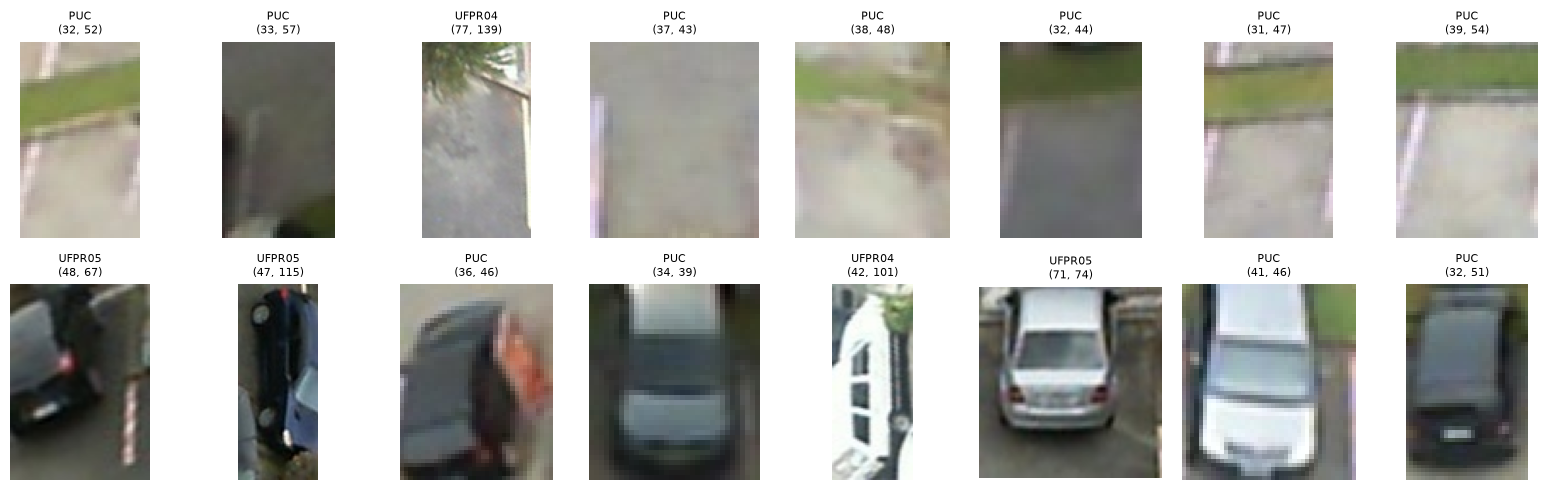

In [20]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 8, figsize=(16,5))
for row, label in enumerate(["Empty", "Occupied"]):
    samples = seg_df[seg_df.label==label].sample(8, random_state=0)
    for ax, (_, r) in zip(axes[row], samples.iterrows()):
        img = Image.open(r.path)
        ax.imshow(img)
        ax.set_title(f"{r.lot}\n{img.size}", fontsize=8)
        ax.axis("off")
plt.tight_layout()
plt.show()

C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 48744 (\N{HANGUL SYLLABLE BBAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52284 (\N{HANGUL SYLLABLE CASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO})

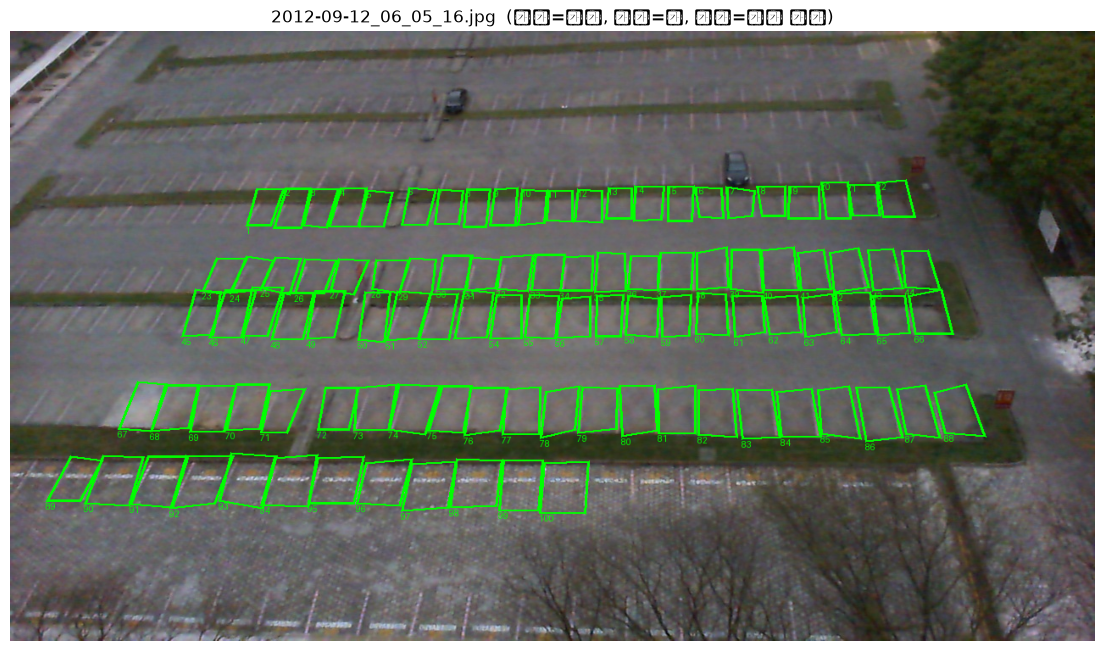

In [21]:
import xml.etree.ElementTree as ET
from PIL import ImageDraw

img_path = sample_orig
xml_path = img_path.with_suffix(".xml")

root = ET.parse(xml_path).getroot()
img = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img)

for space in root.iter("space"):
    occ = space.get("occupied")
    pts = [(int(p.get("x")), int(p.get("y"))) for p in space.findall("./contour/point")]
    color = "red" if occ == "1" else "lime" if occ == "0" else "yellow"
    draw.polygon(pts, outline=color, width=3)
    draw.text(pts[0], space.get("id"), fill=color)
plt.figure(figsize=(14, 8)); plt.imshow(img); plt.axis("off")
plt.title(f"{img_path.name}  (빨강=찼음, 초록=빔, 노랑=라벨 없음)"); plt.show()

In [22]:
import numpy as np

TEST_LOT = "PUC"   
VAL_FRAC = 0.15       

# (1) "주차장|날짜"를 하나의 그룹 키로
seg_df["group"] = seg_df["lot"] + "|" + seg_df["date"]

# (2) test 주차장을 뺀 나머지의 고유 그룹 목록
groups = seg_df.loc[seg_df.lot != TEST_LOT, ["lot", "date", "group"]].drop_duplicates()

# (3) 주차장마다 날짜의 15%를 무작위로 골라 val로
val_groups = groups.groupby("lot").sample(frac=VAL_FRAC, random_state=0)
val_keys = set(val_groups["group"])

# (4) 각 행에 split 이름 붙이기
seg_df["split"] = np.where(seg_df.lot == TEST_LOT, "test",
                  np.where(seg_df.group.isin(val_keys), "val", "train"))

display(pd.crosstab([seg_df.split, seg_df.lot], seg_df.label, margins=True))

label          Empty  Occupied     All
split lot                             
test  PUC     229994    194229  424223
train UFPR04   49792     40688   90480
      UFPR05   63752     73636  137388
val   UFPR04    9926      5437   15363
      UFPR05    4607     23790   28397
All           358071    337780  695851

In [22]:
tr = set(seg_df.loc[seg_df.split == "train", "group"])
va = set(seg_df.loc[seg_df.split == "val",   "group"])
te = set(seg_df.loc[seg_df.split == "test",  "group"])

print("train∩val :", tr & va)    # 둘 다 set() 나와야 정상
print("train∩test:", tr & te)
print("그룹 수:", len(tr), len(va), len(te))

train∩val : set()
train∩test: set()
그룹 수: 54 9 38


In [23]:
parts = []
for (split, label), g in seg_df.groupby(["split", "label"]):
    n = len(g)
    parts.append(g.sample(n=n, random_state=0))
sub_df = pd.concat(parts, ignore_index=True)
display(pd.crosstab(sub_df.split, sub_df.label, margins=True))
display(pd.crosstab([sub_df.split, sub_df.weather], sub_df.label))

label,Empty,Occupied,All
split,,,
test,229994,194229,424223
train,113544,114324,227868
val,14533,29227,43760
All,358071,337780,695851


label           Empty  Occupied
split weather                  
test  Cloudy    90417     42363
      Rainy     27951     55105
      Sunny    111626     96761
train Cloudy    45129     32222
      Rainy      7545      7361
      Sunny     60870     74741
val   Cloudy     5850     13150
      Rainy       913      1068
      Sunny      7770     15009

In [25]:
import shutil
from tqdm.auto import tqdm  

DATA_DIR = Path("datasets/pklot_cls")

for r in tqdm(sub_df.itertuples(), total=len(sub_df)):
    src = Path(r.path)
    dst = DATA_DIR / r.split / r.label.lower() / f"{r.lot}_{src.name}"
    dst.parent.mkdir(parents=True, exist_ok=True)   # 폴더 없으면 만들기
    if not dst.exists():                            # 다시 실행해도 중복 복사 안 함
        shutil.copy(src, dst)

C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 695851/695851 [6:56:44<00:00, 27.83it/s]    


In [30]:
sum = 0
for split in ["train", "val", "test"]:
    for cls in ["empty", "occupied"]:
        n = len(list((DATA_DIR / split / cls).glob("*.jpg")))
        sum += n
        print(f"{split:5s} {cls:9s} {n:>6d}")
print(sum)

train empty     113544
train occupied  114324
val   empty      14533
val   occupied   29227
test  empty     229994
test  occupied  194229
695851


In [29]:
from ultralytics import YOLO

# 장치 선택: NVIDIA GPU면 0, 맥(M칩)이면 "mps", 둘 다 없으면 "cpu"
DEVICE = 0 if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

model = YOLO("yolo26n-cls.pt")        # ImageNet으로 사전학습된 가장 작은 분류 모델

results = model.train(
    data=str(DATA_DIR),   # 폴더 경로만 주면 train/val을 알아서 찾음
    epochs=10,            # 첫 실험이라 짧게
    imgsz=96,             # 크롭이 작아서(40~100px) 96이면 충분
    batch=128,            # 메모리 부족 에러가 나면 64, 32로 줄이기
    device=DEVICE,
    workers=2,            # 노트북/주피터에서는 작게 두는 게 안전
    project="runs", name="cls_v1",
)
print("best 가중치:", model.trainer.best)

device: 0
New https://pypi.org/project/ultralytics/8.4.172 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.171  Python-3.11.16 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX A6000, 49140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets\pklot_cls, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=96, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-cls.pt

In [4]:
from pathlib import Path
for p in Path("runs").rglob("*.pt"):
    print(p)

runs\classify\runs\cls_v1\weights\best.pt
runs\classify\runs\cls_v1\weights\last.pt


In [6]:
from ultralytics import YOLO

best = YOLO(r"runs\classify\runs\cls_v1\weights\best.pt")

print(best.names)

{0: 'empty', 1: 'occupied'}


In [10]:
# ===== 0. 설정 (커널 재시작하면 이것부터 실행) =====
import torch, cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

DEVICE   = 0 if torch.cuda.is_available() else "cpu"
SEG_ROOT = Path("data/PKLot/PKLotSegmented")
DATA_DIR = Path("datasets/pklot_cls")
BEST_PT  = "runs/classify/runs/cls_v1/weights/best.pt"

best = YOLO(BEST_PT)
print("device:", DEVICE, "| classes:", best.names)

device: 0 | classes: {0: 'empty', 1: 'occupied'}


C:\Users\HP\anaconda3\envs\SmartPkLot\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ultralytics 8.4.171  Python-3.11.16 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX A6000, 49140MiB)
YOLO26n-cls summary (fused): 47 layers, 1,528,586 parameters, 0 gradients, 3.2 GFLOPs
train: D:\SmartParkingSystem\datasets\pklot_cls\train... found 227868 images in 2 classes  
val: D:\SmartParkingSystem\datasets\pklot_cls\val... found 43760 images in 2 classes  
test: D:\SmartParkingSystem\datasets\pklot_cls\test... found 424223 images in 2 classes  
WARNING test: Slow image access detected (ping: 10.24.0 ms, read: 0.00.0 MB/s, size: 1.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
test: Scanning D:\SmartParkingSystem\datasets\pklot_cls\test... 424223 images, 0 corrupt: 100% ━━━━━━━━━━━━ 424223/424223 126.5it/s 55:540.1ss3
test: New cache created: D:\SmartParkingSystem\datasets\pklot_cls\test.cache
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 26514/26514 84.6it/s 5:13<0.0ss
       

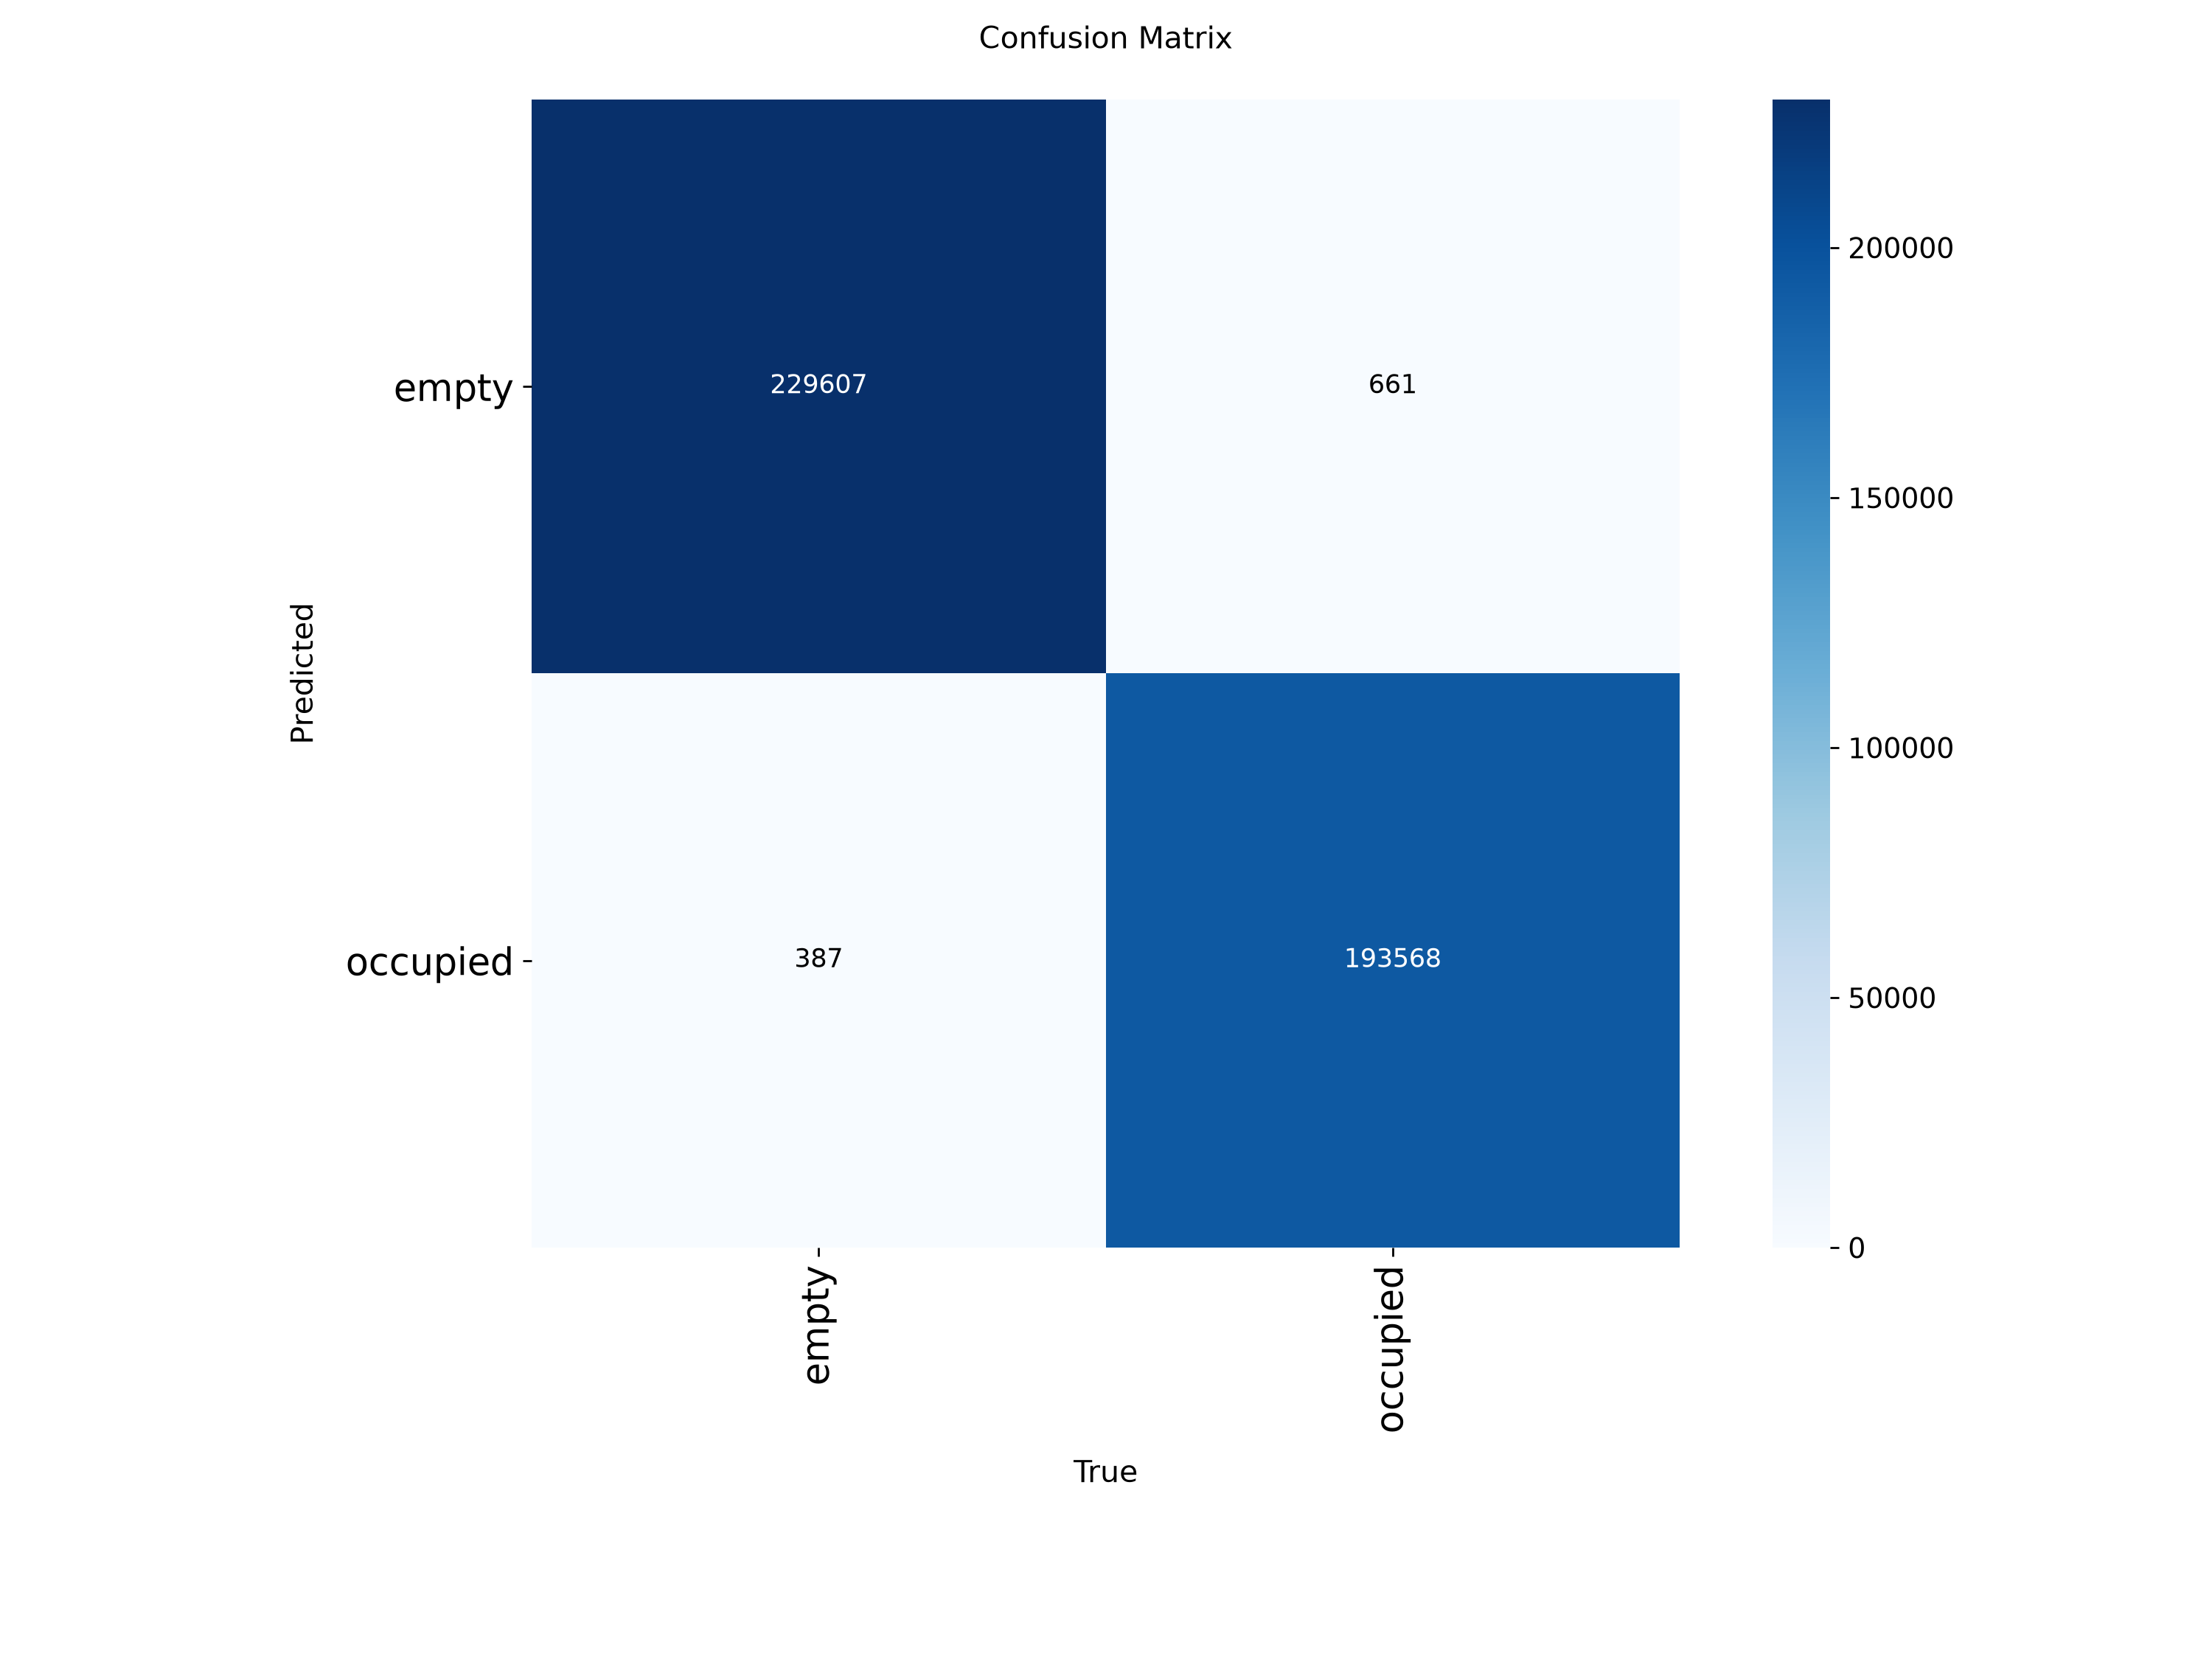

In [11]:
DATA_DIR = Path("datasets/pklot_cls")
metrics = best.val(data=str(DATA_DIR), split="test", imgsz=96, device=DEVICE)
print("test 정확도 (처음 보는 주차장):", metrics.top1)

from IPython.display import Image as IPImage
display(IPImage(str(Path(metrics.save_dir) / "confusion_matrix.png"), width=450))

OutOfMemoryError: CUDA out of memory. Tried to allocate 43.70 GiB. GPU 0 has a total capacity of 47.99 GiB of which 0 bytes is free. Of the allocated memory 116.56 GiB is allocated by PyTorch, and 14.58 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)